# Importing Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


### Model and Data Initialization

The optimized portfolio dataset, historical asset returns, expected returns, and annualized covariance matrix were loaded from their respective serialized files. Consistency checks were performed to ensure that the asset ordering was identical across the expected returns, covariance matrix, and return data, preventing any misalignment during portfolio calculations. The pre-trained Random Forest and XGBoost regression and classification models were then loaded for portfolio prediction tasks. Finally, the portfolio data structure, asset names, total number of assets, risk-free rate (6%), and a mapping between asset names and their corresponding indices were initialized for use in the optimization and prediction process.

In [ ]:
portfolio_data = joblib.load("portfolio_data_optimized.pkl")   # simulated random portfolios
returns = joblib.load("Returns.pkl")
expected_returns = joblib.load("Expected_Returns.pkl")
cov_matrix = joblib.load("Covariance.pkl")
assert list(expected_returns.index) == list(returns.columns)
assert list(cov_matrix.index) == list(returns.columns)
assert list(cov_matrix.columns) == list(returns.columns)

print("✅ All assets are aligned.")
 
rf_reg = joblib.load("rfr.pkl")
xgb_reg = joblib.load("xgbr.pkl")
rf_cls = joblib.load("rfc.pkl")
xgb_cls = joblib.load("xgbc.pkl")
 
print("Portfolio data columns:", list(portfolio_data.columns))
print("Assets:", list(returns.columns))
 
n_assets = len(expected_returns)
# Assumption: fixed 6% risk-free rate for reproducibility (see Assumptions section).
# Approximates recent short-term T-bill yields rather than a live-pulled rate.
risk_free_rate = 0.06
asset_index = {asset: i for i, asset in enumerate(returns.columns)}




✅ All assets are aligned.
Portfolio data columns: ['BTC-USD', 'OPGSX', 'VBTLX', 'VDE', 'VGSLX', 'VTIAX', 'VTSAX', 'Volatility', 'Risk_category', 'Expected_Return', 'Portfolio_Volatility', 'Sharpe_Ratio']
Assets: ['BTC-USD', 'OPGSX', 'VBTLX', 'VDE', 'VGSLX', 'VTIAX', 'VTSAX']


### Efficient Frontier Visualization and Portfolio Selection

The performance of the generated portfolios was visualized using a scatter plot, where **annual portfolio volatility** was plotted against the **expected annual return**. Each portfolio was color-coded according to its **Sharpe Ratio**, enabling easy identification of portfolios with superior risk-adjusted performance. From the simulated portfolios, the portfolio with the **highest Sharpe Ratio** (maximum risk-adjusted return) and the portfolio with the **lowest volatility** (minimum risk) were identified and displayed. These two optimal portfolios were then highlighted on the efficient frontier using distinct markers, providing a clear visual comparison between the maximum Sharpe portfolio and the minimum volatility portfolio.

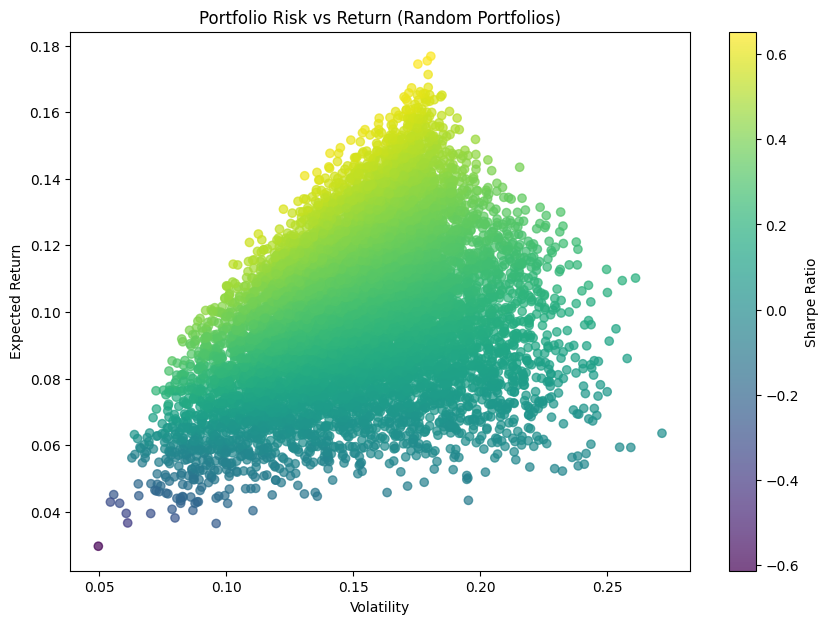

Best random portfolio by Sharpe Ratio
Ticker
BTC-USD                 0.095794
OPGSX                   0.114774
VBTLX                   0.054893
VDE                     0.001555
VGSLX                   0.042882
VTIAX                   0.015584
VTSAX                   0.674517
Volatility                0.1754
Risk_category               High
Expected_Return         0.174446
Portfolio_Volatility      0.1754
Sharpe_Ratio            0.652487
Name: 2072, dtype: object

Best random portfolio by minimum volatility
Ticker
BTC-USD                 0.007415
OPGSX                   0.020371
VBTLX                   0.877763
VDE                     0.040657
VGSLX                    0.02576
VTIAX                   0.024238
VTSAX                   0.003797
Volatility              0.049556
Risk_category                Low
Expected_Return         0.029637
Portfolio_Volatility    0.049556
Sharpe_Ratio           -0.612689
Name: 4713, dtype: object


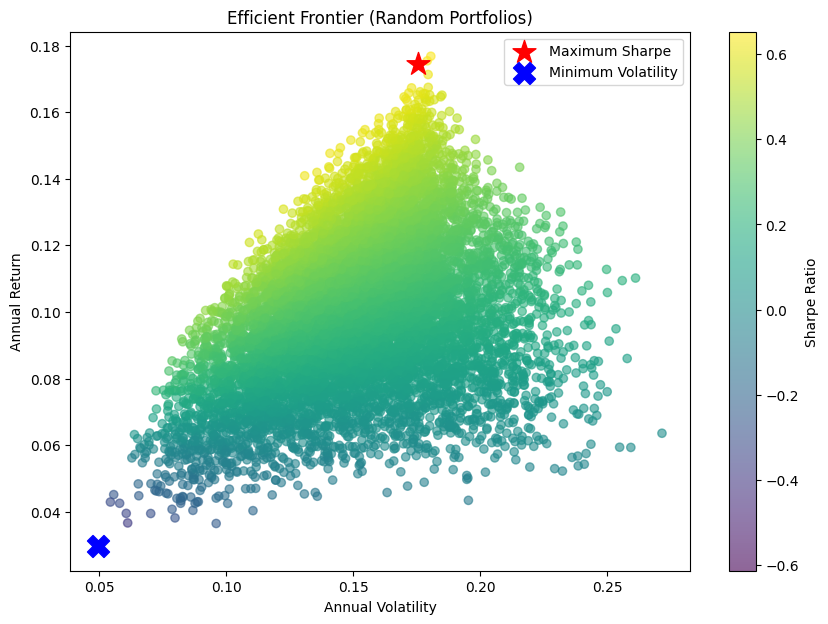

In [3]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    portfolio_data["Portfolio_Volatility"],
    portfolio_data["Expected_Return"],
    c=portfolio_data["Sharpe_Ratio"],
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Portfolio Risk vs Return (Random Portfolios)")
plt.show()
 
max_sharpe_random = portfolio_data.loc[portfolio_data["Sharpe_Ratio"].idxmax()]
min_vol_random = portfolio_data.loc[portfolio_data["Portfolio_Volatility"].idxmin()]
 
print("=" * 50)
print("Best random portfolio by Sharpe Ratio")
print("=" * 50)
print(max_sharpe_random)
print()
print("=" * 50)
print("Best random portfolio by minimum volatility")
print("=" * 50)
print(min_vol_random)
 
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    portfolio_data["Portfolio_Volatility"],
    portfolio_data["Expected_Return"],
    c=portfolio_data["Sharpe_Ratio"],
    cmap="viridis",
    alpha=0.6,
)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.scatter(
    max_sharpe_random["Portfolio_Volatility"],
    max_sharpe_random["Expected_Return"],
    color="red", marker="*", s=300, label="Maximum Sharpe",
)
plt.scatter(
    min_vol_random["Portfolio_Volatility"],
    min_vol_random["Expected_Return"],
    color="blue", marker="X", s=250, label="Minimum Volatility",
)
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier (Random Portfolios)")
plt.legend()
plt.show()



### Portfolio Optimization Functions

Several objective functions were defined to evaluate the performance of a portfolio based on its asset allocation. The **portfolio return** function computes the expected annual return as the weighted sum of the individual asset expected returns, while the **portfolio volatility** function calculates the portfolio's annual risk using the asset weights and the annualized covariance matrix. The **Sharpe Ratio** function measures the portfolio's risk-adjusted return by comparing its excess return over the **6% risk-free rate** to its volatility, with a safeguard to prevent division by zero when the portfolio volatility is extremely small. To facilitate optimization using numerical minimization algorithms, the negative of the Sharpe Ratio was defined as the objective function, allowing the optimizer to maximize the Sharpe Ratio by minimizing its negative value. Finally, the optimization bounds were set to restrict each asset weight between **0 and 1** (no short selling), and an initial portfolio was created by assigning equal weights to all assets.

In [4]:
def portfolio_return(weights):
    return np.dot(weights, expected_returns)
 
 
def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix.values @ weights)
 
 
def sharpe_ratio(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    if vol < 1e-12:
      return -np.inf

    return (ret-risk_free_rate)/vol
 
 
def negative_sharpe(weights):
    return -sharpe_ratio(weights)
 
 
bounds = tuple((0, 1) for _ in range(n_assets))
initial_weights = np.ones(n_assets) / n_assets


### Portfolio Optimization with Constraints

To support constrained portfolio optimization, a set of helper functions was defined to specify investment restrictions. The **maximum weight constraint** limits the allocation of a selected asset to a specified upper bound, while the **minimum weight constraint** ensures that an asset receives at least a predefined minimum allocation. The **equal weight constraint** fixes the weight of a particular asset to an exact value when required. In addition, a **budget constraint** enforces that the sum of all portfolio weights equals **1 (100%)**, ensuring that the entire investment capital is allocated. These constraints are incorporated into an optimization function that employs the **Sequential Least Squares Programming (SLSQP)** algorithm to maximize the portfolio's Sharpe Ratio by minimizing its negative value. Upon successful optimization, the function returns the optimal asset allocation along with the corresponding **expected return**, **portfolio volatility**, and **Sharpe Ratio**, which characterize the performance of the optimized portfolio.

In [5]:
def max_weight_constraint(asset_name, max_weight):
    idx = asset_index[asset_name]
    return {
        "type": "ineq",
        "fun": lambda w, idx=idx, max_weight=max_weight: max_weight - w[idx],
    }
 
 
def min_weight_constraint(asset_name, min_weight):
    idx = asset_index[asset_name]
    return {
        "type": "ineq",
        "fun": lambda w, idx=idx, min_weight=min_weight: w[idx] - min_weight,
    }
 
 
def equal_weight_constraint(asset_name, weight):
    idx = asset_index[asset_name]
    return {
        "type": "eq",
        "fun": lambda w, idx=idx, weight=weight: w[idx] - weight,
    }
 
 
def budget_constraint():
    return {"type": "eq", "fun": lambda w: np.sum(w) - 1}
 
 
def optimize_portfolio(constraints, bounds=bounds, x0=initial_weights):
    """Run max-Sharpe optimization under the given constraints."""
    result = minimize(
    negative_sharpe,
    x0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 1000,
        "ftol": 1e-9
    }
)
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")
 
    weights = result.x
    portfolio_df = pd.DataFrame({"Asset": returns.columns, "Weight": weights})
    metrics = {
        "Expected Return": portfolio_return(weights),
        "Volatility": portfolio_volatility(weights),
        "Sharpe Ratio": sharpe_ratio(weights),
    }
    return portfolio_df, metrics, weights


In [6]:
unconstrained_portfolio, unconstrained_metrics, unconstrained_weights = optimize_portfolio(
    [budget_constraint()]
)
 
print()
print("=" * 60)
print("UNCONSTRAINED MAX-SHARPE PORTFOLIO")
print("=" * 60)
print(unconstrained_portfolio)
print(unconstrained_metrics)



UNCONSTRAINED MAX-SHARPE PORTFOLIO
     Asset        Weight
0  BTC-USD  5.214705e-01
1    OPGSX  1.535056e-01
2    VBTLX  8.978549e-17
3      VDE  0.000000e+00
4    VGSLX  0.000000e+00
5    VTIAX  2.518060e-17
6    VTSAX  3.250239e-01
{'Expected Return': np.float64(0.4161729162171062), 'Volatility': np.float64(0.38018401703243254), 'Sharpe Ratio': np.float64(0.9368434764755563)}


### Efficient Frontier Construction

The efficient frontier was generated by solving a series of constrained optimization problems, each corresponding to a predefined **target portfolio return**. For every target return, the optimization minimized the portfolio's annual volatility while satisfying two constraints: the **budget constraint**, which ensures that the sum of all asset weights equals one, and the **target return constraint**, which forces the portfolio to achieve the specified expected return. The optimization was performed using the **Sequential Least Squares Programming (SLSQP)** algorithm with the previously defined weight bounds. The optimized portfolio risk, return, and asset weights for each successful solution were stored to construct the efficient frontier. The resulting frontier was then plotted alongside the randomly generated portfolios, illustrating the set of optimal portfolios that provide the **minimum possible risk for each level of expected return**. Finally, the Sharpe Ratio was computed for every portfolio on the efficient frontier, and the portfolio with the **maximum Sharpe Ratio** was identified as the optimal risk-adjusted portfolio, with its expected return, volatility, and asset allocation reported.

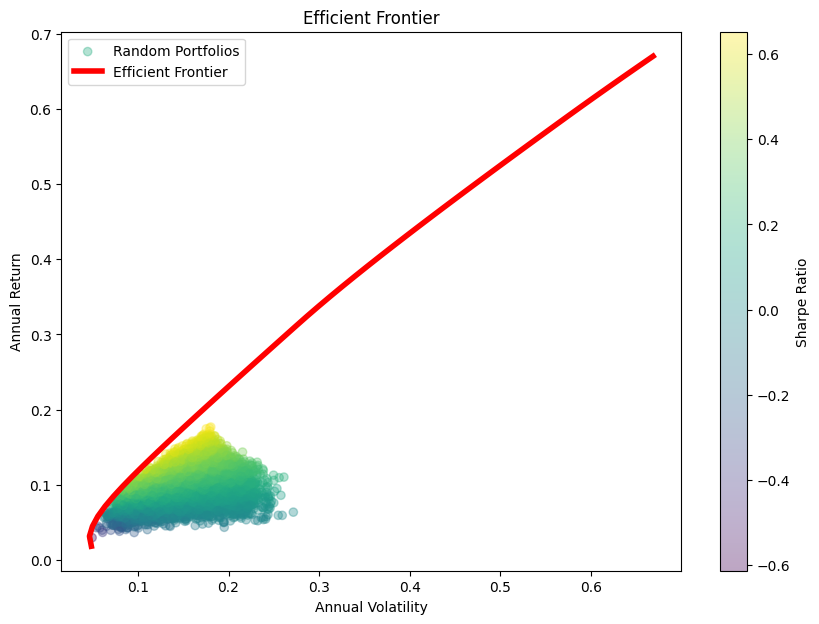

     Return      Risk
0  0.018237  0.048724
1  0.031538  0.046621
2  0.044840  0.049968
3  0.058142  0.055927
4  0.071443  0.063922

Maximum Sharpe point on the computed frontier
Return: 0.4172843235707808
Risk  : 0.3813708502887637
Weights:
Ticker
BTC-USD    5.235301e-01
OPGSX      1.534735e-01
VBTLX      1.256590e-16
VDE        0.000000e+00
VGSLX      0.000000e+00
VTIAX      1.079865e-16
VTSAX      3.229964e-01
dtype: float64


In [7]:
def minimize_volatility(weights):
    return portfolio_volatility(weights)
 
 
target_returns = np.linspace(expected_returns.min(), expected_returns.max(), 50)
 
efficient_risk = []
efficient_return = []
efficient_weights = []
 
for target in target_returns:
    frontier_constraints = (
        budget_constraint(),
        {"type": "eq", "fun": lambda w, target=target: portfolio_return(w) - target},
    )
    result = minimize(
        minimize_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=frontier_constraints,
    )
    if result.success:
        efficient_return.append(portfolio_return(result.x))
        efficient_risk.append(portfolio_volatility(result.x))
        efficient_weights.append(result.x)
    else:
        print(f"Target return {target:.4f} failed: {result.message}")
 
plt.figure(figsize=(10, 7))
plt.scatter(
    portfolio_data["Portfolio_Volatility"],
    portfolio_data["Expected_Return"],
    c=portfolio_data["Sharpe_Ratio"],
    cmap="viridis",
    alpha=0.35,
    label="Random Portfolios",
)
plt.plot(efficient_risk, efficient_return, color="red", linewidth=4, label="Efficient Frontier")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier")
plt.legend()
plt.colorbar(label="Sharpe Ratio")
plt.show()
 
efficient_frontier = pd.DataFrame({"Return": efficient_return, "Risk": efficient_risk})
print(efficient_frontier.head())
 
frontier_sharpe = (np.array(efficient_return) - risk_free_rate) / np.array(efficient_risk)
best_idx = np.argmax(frontier_sharpe)
 
print()
print("Maximum Sharpe point on the computed frontier")
print("Return:", efficient_return[best_idx])
print("Risk  :", efficient_risk[best_idx])
print("Weights:")
print(pd.Series(efficient_weights[best_idx], index=returns.columns))


### Final Constrained Portfolio Optimization

A final portfolio optimization was performed by maximizing the **Sharpe Ratio** while satisfying a set of practical investment constraints. In addition to the **budget constraint**, which ensures that the total asset allocation equals **100%**, the portfolio was required to achieve an **expected annual return of at least 15%** and maintain an **annual volatility not exceeding 18%**. To control portfolio risk and diversification, the allocation to **BTC-USD** was restricted to a maximum of **20%**, **VGSLX** was limited to **10%**, and **VBTLX** was required to have a minimum allocation of **25%**. The optimization was carried out using the **Sequential Least Squares Programming (SLSQP)** algorithm, and the resulting optimal asset weights, along with the portfolio's expected return, volatility, and Sharpe Ratio, were reported as the final constrained portfolio.

In [8]:
final_constraints = [
    budget_constraint(),
    {"type": "ineq", "fun": lambda w: portfolio_return(w) - 0.15},   # return >= 15%
    {"type": "ineq", "fun": lambda w: 0.18 - portfolio_volatility(w)},  # volatility <= 18%
    max_weight_constraint("BTC-USD", 0.20),
    max_weight_constraint("VGSLX", 0.10),
    min_weight_constraint("VBTLX", 0.25),
]
 
final_portfolio, final_metrics, final_weights = optimize_portfolio(final_constraints)
 
print()
print("=" * 60)
print("FINAL CONSTRAINED PORTFOLIO")
print("=" * 60)
print(final_portfolio)
print(final_metrics)



FINAL CONSTRAINED PORTFOLIO
     Asset        Weight
0  BTC-USD  2.000000e-01
1    OPGSX  1.007315e-01
2    VBTLX  2.920453e-01
3      VDE  4.216116e-16
4    VGSLX  4.264548e-16
5    VTIAX  0.000000e+00
6    VTSAX  4.072232e-01
{'Expected Return': np.float64(0.20834560930998058), 'Volatility': np.float64(0.18000000000000402), 'Sharpe Ratio': np.float64(0.8241422739443182)}


### Machine Learning-Based Portfolio Validation

The optimized portfolio obtained through Modern Portfolio Theory (MPT) was further validated using the pre-trained **Random Forest** and **XGBoost** machine learning models. The optimized asset weights were first converted into a feature vector and provided as input to both regression and classification models. The regression models predicted the portfolio's **annual volatility**, while the classification models predicted its corresponding **risk category**. Additionally, the XGBoost classifier produced class probabilities to indicate the confidence associated with each predicted risk class. Finally, the predicted volatility and risk classifications were compared with the mathematically computed **expected return**, **portfolio volatility**, and **Sharpe Ratio**, providing a cross-validation of the optimized portfolio and demonstrating the consistency between the analytical MPT framework and the machine learning models.

In [9]:
portfolio_features = pd.DataFrame([final_weights], columns=returns.columns)
 
rf_vol_pred = rf_reg.predict(portfolio_features)[0]
xgb_vol_pred = xgb_reg.predict(portfolio_features)[0]
rf_risk_pred = rf_cls.predict(portfolio_features)[0]
xgb_risk_pred = xgb_cls.predict(portfolio_features)[0]
xgb_risk_proba = xgb_cls.predict_proba(portfolio_features)
 
print()
print("=" * 60)
print("FINAL PORTFOLIO — MODEL CROSS-CHECK")
print("=" * 60)
print(portfolio_features.T)
print()
print(f"Expected Return       : {final_metrics['Expected Return']:.4f}")
print(f"Volatility (math)     : {final_metrics['Volatility']:.4f}")
print(f"Sharpe Ratio          : {final_metrics['Sharpe Ratio']:.4f}")
print(f"Volatility (RF pred)  : {rf_vol_pred:.4f}")
print(f"Volatility (XGB pred) : {xgb_vol_pred:.4f}")
print(f"Risk class (RF)       : {rf_risk_pred}")
print(f"Risk class (XGB)      : {xgb_risk_pred}")
print(f"Risk class probs (XGB): {xgb_risk_proba}")



FINAL PORTFOLIO — MODEL CROSS-CHECK
                    0
Ticker               
BTC-USD  2.000000e-01
OPGSX    1.007315e-01
VBTLX    2.920453e-01
VDE      4.216116e-16
VGSLX    4.264548e-16
VTIAX    0.000000e+00
VTSAX    4.072232e-01

Expected Return       : 0.2083
Volatility (math)     : 0.1800
Sharpe Ratio          : 0.8241
Volatility (RF pred)  : 0.1375
Volatility (XGB pred) : 0.1355
Risk class (RF)       : 1
Risk class (XGB)      : 1
Risk class probs (XGB): [[1.2257871e-03 9.9872619e-01 4.7576064e-05 4.4337941e-07]]
